# LSA Dataset Explorer

Exploración end-to-end para validación de Fase 0 del proyecto Avatar AI.

**Preguntas a responder:**
- ¿Los videos tienen subtítulos? ¿Son usables?
- ¿Están sincronizados?
- ¿MediaPipe extrae keypoints de buena calidad?
- ¿Qué estructura de dataset tiene sentido para Juan?

In [1]:
import sys
sys.path.insert(0, '../scripts')

import json
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import mediapipe as mp
import numpy as np

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

print('Config cargada OK')

Config cargada OK


## Sección 1 — Descarga de video GCBA

Pegar una URL de YouTube de un video GCBA con intérprete LSA.

In [2]:
from download import download_video

# Cambiar por URL real de video GCBA
VIDEO_URL = "https://www.youtube.com/watch?v=u07hL-EzTpY&list=PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8"

download_video(VIDEO_URL, config)

# Listar archivos descargados
raw_files = list(Path(config['paths']['raw']).glob('*'))
sub_files = list(Path(config['paths']['subtitles']).glob('*'))
print('Videos:', [f.name for f in raw_files])
print('Subtítulos:', [f.name for f in sub_files])

[youtube:tab] Extracting URL: https://www.youtube.com/watch?v=u07hL-EzTpY&list=PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8
[youtube:tab] Downloading playlist PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8 - add --no-playlist to download just the video u07hL-EzTpY
[youtube:tab] PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8: Downloading webpage
[youtube:tab] Extracting URL: https://www.youtube.com/playlist?list=PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8
[youtube:tab] PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8: Downloading webpage
[youtube:tab] PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8: Redownloading playlist API JSON with unavailable videos
[download] Downloading playlist: Guia de Información 2018/2019 | Servicios Sociales Zonales
[youtube:tab] PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8 page 1: Downloading API JSON
[info] Writing playlist metadata as JSON to: data/raw/PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8.info.json
[youtube:tab] Playlist Guia de Información 2018/2019 | Servicios Sociales Zonales: Downloading 3 items of 3
[download] Downloading item 1 o

[youtube] u07hL-EzTpY: Downloading android vr player API JSON
[info] u07hL-EzTpY: Downloading 1 format(s): 137+140
[info] There are no subtitles for the requested languages
[info] Writing video metadata as JSON to: data/raw/u07hL-EzTpY.info.json
[SubtitlesConvertor] There aren't any subtitles to convert
[download] Destination: data/raw/u07hL-EzTpY.f137.mp4
[download] 100% of    8.89MiB in 00:00:01 at 6.17MiB/s     
[download] Destination: data/raw/u07hL-EzTpY.f140.m4a
[download] 100% of  816.17KiB in 00:00:01 at 667.49KiB/s   
[download] Downloading item 2 of 3
[youtube] Extracting URL: https://www.youtube.com/watch?v=T_vgQJhMWf8
[youtube] T_vgQJhMWf8: Downloading webpage


[youtube] T_vgQJhMWf8: Downloading android vr player API JSON
[info] T_vgQJhMWf8: Downloading 1 format(s): 137+140
[info] There are no subtitles for the requested languages
[info] Writing video metadata as JSON to: data/raw/T_vgQJhMWf8.info.json
[SubtitlesConvertor] There aren't any subtitles to convert
[download] Destination: data/raw/T_vgQJhMWf8.f137.mp4
[download] 100% of    7.64MiB in 00:00:02 at 3.71MiB/s     
[download] Destination: data/raw/T_vgQJhMWf8.f140.m4a
[download] 100% of  689.91KiB in 00:00:00 at 1.29MiB/s   
[download] Downloading item 3 of 3
[youtube] Extracting URL: https://www.youtube.com/watch?v=2iYRa7hKg2g
[youtube] 2iYRa7hKg2g: Downloading webpage


[youtube] 2iYRa7hKg2g: Downloading android vr player API JSON
[info] 2iYRa7hKg2g: Downloading 1 format(s): 137+140
[info] There are no subtitles for the requested languages
[info] Writing video metadata as JSON to: data/raw/2iYRa7hKg2g.info.json
[SubtitlesConvertor] There aren't any subtitles to convert
[download] Destination: data/raw/2iYRa7hKg2g.f137.mp4
[download] 100% of    5.20MiB in 00:00:01 at 3.10MiB/s   
[download] Destination: data/raw/2iYRa7hKg2g.f140.m4a
[download] 100% of  478.20KiB in 00:00:00 at 1.01MiB/s   
[info] Writing updated playlist metadata as JSON to: data/raw/PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8.info.json
[download] Finished downloading playlist: Guia de Información 2018/2019 | Servicios Sociales Zonales
Done. Video in data/raw, subtitles in data/subtitles
Videos: ['u07hL-EzTpY.f140.m4a', 'PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8.info.json', 'T_vgQJhMWf8.f137.mp4', 'T_vgQJhMWf8.info.json', '2iYRa7hKg2g.f140.m4a', 'u07hL-EzTpY.info.json', 'T_vgQJhMWf8.f140.m4a', '2iYRa7

In [4]:
# Seleccionar video y subtítulo para el análisis
VIDEO_PATH = sorted(Path(config['paths']['raw']).glob('*.mp4'))[0]
#SUB_PATH = sorted(Path(config['paths']['subtitles']).glob('*.srt'))[0]

print(f'Video: {VIDEO_PATH.name}')
#print(f'Subtítulo: {SUB_PATH.name}')

# Metadatos del video
cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = total_frames / fps
cap.release()

print(f'\nResolución: {width}x{height}')
print(f'FPS: {fps:.1f}')
print(f'Duración: {duration:.1f}s ({duration/60:.1f} min)')
print(f'Frames totales: {total_frames}')

Video: 2iYRa7hKg2g.f137.mp4

Resolución: 1920x1080
FPS: 30.0
Duración: 30.1s (0.5 min)
Frames totales: 903


## Sección 2 — Análisis de subtítulos

In [ ]:
from extract_subs import load_subtitles

segments = load_subtitles(SUB_PATH)
print(f'Total segmentos: {len(segments)}')
print()

df = pd.DataFrame([
    {'start': s.start, 'end': s.end, 'duration': s.end - s.start, 'text': s.text}
    for s in segments
])
print(df.head(10).to_string(index=False))

In [ ]:
# Métricas de riqueza
all_text = ' '.join(df['text'])
words = all_text.lower().split()
unique_words = set(words)

print(f'Palabras totales: {len(words)}')
print(f'Vocabulario único: {len(unique_words)}')
print(f'Cobertura temporal: {df["duration"].sum():.1f}s de {duration:.1f}s ({df["duration"].sum()/duration*100:.1f}%)')
print(f'Duración promedio por segmento: {df["duration"].mean():.2f}s')

## Sección 3 — Chequeo de sincronización

In [ ]:
from sync_subs import analyze_sync

sync = analyze_sync(VIDEO_PATH, SUB_PATH)
print('Resultado de sincronización:')
for k, v in sync.items():
    status = '✓' if k == 'sync_ok' and v else ('✗' if k == 'sync_ok' else ' ')
    print(f'  {status} {k}: {v}')

In [ ]:
# Visualizar timeline de subtítulos sobre duración del video
fig, ax = plt.subplots(figsize=(14, 2))
ax.barh(0, duration, color='lightgray', height=0.4, label='Video')
for _, row in df.iterrows():
    ax.barh(0, row['duration'], left=row['start'], color='steelblue', height=0.4, alpha=0.7)

ax.set_xlabel('Tiempo (segundos)')
ax.set_yticks([])
ax.set_title(f'Cobertura de subtítulos — {sync["coverage_ratio"]*100:.1f}% del video')
patches = [mpatches.Patch(color='lightgray', label='Video'), mpatches.Patch(color='steelblue', alpha=0.7, label='Subtítulos')]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.show()

## Sección 4 — Extracción de keypoints con MediaPipe

In [ ]:
from extract_keypoints import extract_keypoints

# Procesar primer segmento como prueba
seg = segments[0]
frame_start = int(seg.start * fps)
frame_end = int(seg.end * fps)

print(f'Procesando segmento 0: "{seg.text}"')
print(f'Frames {frame_start} → {frame_end} ({frame_end - frame_start} frames)')

kp_result = extract_keypoints(VIDEO_PATH, config, frame_start, frame_end)
print(f'\nFrames procesados: {kp_result["n_frames_processed"]}')
print(f'Confidence promedio: {kp_result["confidence_avg"]}')
print(f'Tiene pose en frame 0: {kp_result["frames"][0]["pose"] is not None}')
print(f'Tiene mano derecha en frame 0: {kp_result["frames"][0]["right_hand"] is not None}')
print(f'Tiene mano izquierda en frame 0: {kp_result["frames"][0]["left_hand"] is not None}')

In [ ]:
# Visualizar overlay de keypoints sobre un frame
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

cap = cv2.VideoCapture(str(VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)
ret, frame = cap.read()
cap.release()

rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
with mp_holistic.Holistic(
    model_complexity=config['mediapipe']['model_complexity'],
    min_detection_confidence=config['mediapipe']['min_detection_confidence'],
    static_image_mode=True
) as holistic:
    results = holistic.process(rgb)

annotated = rgb.copy()
mp_drawing.draw_landmarks(annotated, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
mp_drawing.draw_landmarks(annotated, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
mp_drawing.draw_landmarks(annotated, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

plt.figure(figsize=(10, 6))
plt.imshow(annotated)
plt.title(f'MediaPipe Holistic — frame {frame_start}\n"{seg.text}"')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Analizar confianza a lo largo de todos los frames del segmento
confidences = [
    np.mean([lm['visibility'] for lm in f['pose']]) if f['pose'] else 0
    for f in kp_result['frames']
]
frame_nums = [f['frame'] for f in kp_result['frames']]

plt.figure(figsize=(12, 3))
plt.plot(frame_nums, confidences, color='steelblue')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='threshold 0.5')
plt.xlabel('Frame')
plt.ylabel('Confidence promedio (pose)')
plt.title(f'Calidad de detección MediaPipe — segmento 0')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Frames con confidence > 0.5: {sum(c > 0.5 for c in confidences)}/{len(confidences)}')

## Sección 5 — Armado de dataset mínimo

In [ ]:
# Procesar los primeros N segmentos para generar dataset de muestra
N_SEGMENTS = 5  # ajustar según tiempo disponible

dataset = []
for seg in segments[:N_SEGMENTS]:
    f_start = int(seg.start * fps)
    f_end = int(seg.end * fps)
    kp = extract_keypoints(VIDEO_PATH, config, f_start, f_end)

    entry = {
        "id": f"{VIDEO_PATH.stem}_{seg.index:04d}",
        "gloss": seg.text,
        "source": VIDEO_PATH.stem,
        "frames": {"start": f_start, "end": f_end},
        "keypoints": kp["frames"],
        "metadata": {
            "intent": None,          # para dataset propio: ej. 'renovar_dni'
            "tramite": None,
            "subtitle_type": "auto_cc",
            "sync_ok": sync["sync_ok"],
            "confidence_avg": kp["confidence_avg"],
            "fps": fps,
            "time_start": seg.start,
            "time_end": seg.end,
        }
    }
    dataset.append(entry)
    print(f'  [{seg.index}] "{seg.text[:50]}" — confidence: {kp["confidence_avg"]}')

print(f'\nDataset: {len(dataset)} entradas')

In [ ]:
# Guardar dataset
output_path = Path(config['paths']['dataset']) / f"{VIDEO_PATH.stem}_sample.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(dataset, f, indent=2, ensure_ascii=False)

print(f'Dataset guardado en: {output_path}')

# Preview de estructura
entry = dataset[0]
preview = {k: v for k, v in entry.items() if k != 'keypoints'}
preview['keypoints'] = f'[{len(entry["keypoints"])} frames, cada uno con pose/left_hand/right_hand]'
print('\nEstructura de una entrada:')
print(json.dumps(preview, indent=2, ensure_ascii=False))

## Resumen — GO / NO-GO

---
## Sección 6 — Análisis de keypoints 1086-features

Compatible con Signformer. Corré en orden: **6.1 → 6.2 → 6.3 → 6.4**

> Generá el JSON si no existe:
> ```bash
> python3 scripts/extract_keypoints.py notebooks/data/raw/2iYRa7hKg2g.f137.mp4 --sample-rate 30 --output /tmp/keypoints_1086.json
> ```

In [1]:
# 6.1 — Estadísticas de detección
import json, numpy as np, matplotlib.pyplot as plt, cv2

KP_JSON    = '/tmp/keypoints_1086.json'
VIDEO_PATH = 'data/raw/2iYRa7hKg2g.f137.mp4'

data   = json.load(open(KP_JSON))
frames = data['frames']
fps    = data['fps']
n      = len(frames)

pose  = sum(1 for f in frames if f['pose_detected'])
face  = sum(1 for f in frames if f['face_detected'])
lhand = sum(1 for f in frames if f['left_hand'])
rhand = sum(1 for f in frames if f['right_hand'])

print(f"Video            : {data['video'].split('/')[-1]}")
print(f"feature_size     : {data['feature_size']}  <- debe ser 1086")
print(f"Frames analizados: {n}  (1 por segundo)")
print()
print(f"Pose detectada   : {pose}/{n}  ({100*pose/n:.0f}%)")
print(f"Cara detectada   : {face}/{n}  ({100*face/n:.0f}%)")
print(f"Mano izquierda   : {lhand}/{n}  ({100*lhand/n:.0f}%)")
print(f"Mano derecha     : {rhand}/{n}  ({100*rhand/n:.0f}%)")
print(f"Confidence avg   : {data['confidence_avg']}")
print()
v = frames[5]['vector']
print(f"Estructura del vector (frame 5):")
print(f"  Pose  [0:66]      — no-cero: {sum(1 for x in v[0:66]     if x != 0.0)}/66")
print(f"  Cara  [66:1002]   — no-cero: {sum(1 for x in v[66:1002]  if x != 0.0)}/936")
print(f"  ManoI [1002:1044] — no-cero: {sum(1 for x in v[1002:1044] if x != 0.0)}/42")
print(f"  ManoD [1044:1086] — no-cero: {sum(1 for x in v[1044:1086] if x != 0.0)}/42")

Video            : 2iYRa7hKg2g.f137.mp4
feature_size     : 1086  <- debe ser 1086
Frames analizados: 31  (1 por segundo)

Pose detectada   : 30/31  (97%)
Cara detectada   : 27/31  (87%)
Mano izquierda   : 17/31  (55%)
Mano derecha     : 14/31  (45%)
Confidence avg   : 0.7341

Estructura del vector (frame 5):
  Pose  [0:66]      — no-cero: 66/66
  Cara  [66:1002]   — no-cero: 936/936
  ManoI [1002:1044] — no-cero: 42/42
  ManoD [1044:1086] — no-cero: 0/42


In [ ]:
# 6.2 — Frame con keypoints dibujados
import ipywidgets as widgets
from IPython.display import display

def unpack_vector(vector, h, w):
    v = np.array(vector, dtype=np.float32)
    to_px = lambda xy: (xy * np.array([w, h])).astype(int)
    return (
        to_px(v[0:66].reshape(33, 2)),
        to_px(v[66:1002].reshape(468, 2)),
        to_px(v[1002:1044].reshape(21, 2)),
        to_px(v[1044:1086].reshape(21, 2)),
    )

def draw_from_vector(video_path, frame_data, fps):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_data['frame'])
    ret, frame = cap.read()
    cap.release()
    if not ret: return None
    h, w = frame.shape[:2]
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pose_px, face_px, lhand_px, rhand_px = unpack_vector(frame_data['vector'], h, w)
    for x, y in face_px:
        if x > 0 or y > 0: cv2.circle(img, (x, y), 1, (180, 180, 180), -1)
    for x, y in pose_px:
        if x > 0 or y > 0: cv2.circle(img, (x, y), 5, (0, 150, 255), -1)
    for x, y in lhand_px:
        if x > 0 or y > 0: cv2.circle(img, (x, y), 6, (255, 120, 0), -1)
    for x, y in rhand_px:
        if x > 0 or y > 0: cv2.circle(img, (x, y), 6, (0, 220, 80), -1)
    return img

slider = widgets.IntSlider(
    min=0, max=int(frames[-1]['frame']/fps), step=1,
    description='Segundo:', continuous_update=False
)
out = widgets.Output()

def mostrar(change):
    segundo = change['new']
    idx = min(range(len(frames)), key=lambda i: abs(frames[i]['frame']/fps - segundo))
    f = frames[idx]
    img = draw_from_vector(VIDEO_PATH, f, fps)
    manos = ('Izq ' if f['left_hand'] else '') + ('Der' if f['right_hand'] else '') or 'ninguna'
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(13, 7))
        ax.imshow(img)
        ax.set_title(
            f't={segundo}s | pose={f["pose_detected"]} | cara={f["face_detected"]} | manos: {manos}\n'
            f'confidence: {f["confidence"]:.3f}  —  '
            'gris=cara  azul=pose  naranja=mano izq  verde=mano der'
        )
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        plt.close()

slider.observe(mostrar, names='value')
display(widgets.VBox([slider, out]))
mostrar({'new': 0})  # mostrar frame inicial

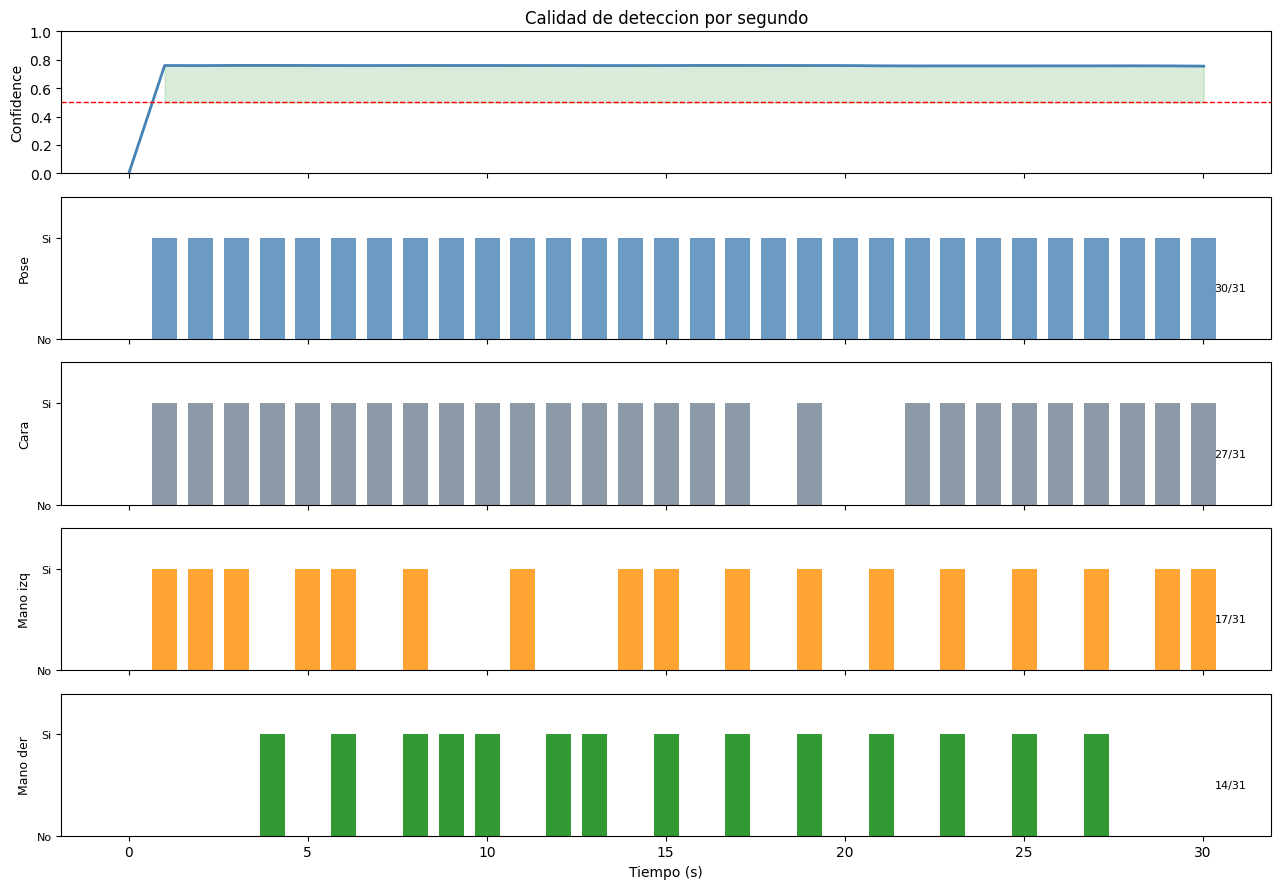

In [3]:
# 6.3 — Deteccion por componente (un grafico por cada uno)
tiempos   = [f['frame'] / fps for f in frames]
confs     = [f['confidence'] for f in frames]

componentes = [
    ('Pose',       [1 if f['pose_detected'] else 0 for f in frames], 'steelblue'),
    ('Cara',       [1 if f['face_detected'] else 0 for f in frames], 'slategray'),
    ('Mano izq',   [1 if f['left_hand']     else 0 for f in frames], 'darkorange'),
    ('Mano der',   [1 if f['right_hand']    else 0 for f in frames], 'green'),
]

fig, axes = plt.subplots(5, 1, figsize=(13, 9), sharex=True)

# Confidence
axes[0].plot(tiempos, confs, color='steelblue', linewidth=2)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1)
axes[0].fill_between(tiempos, confs, 0.5, where=[c>0.5 for c in confs], alpha=0.15, color='green')
axes[0].set_ylabel('Confidence')
axes[0].set_ylim(0, 1)
axes[0].set_title('Calidad de deteccion por segundo')

# Un subplot por componente
for ax, (nombre, valores, color) in zip(axes[1:], componentes):
    ax.bar(tiempos, valores, width=0.7, color=color, alpha=0.8)
    detectados = sum(valores)
    ax.set_ylabel(nombre, fontsize=9)
    ax.set_ylim(0, 1.4)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['No', 'Si'], fontsize=8)
    ax.text(tiempos[-1] + 0.3, 0.5, f'{detectados}/{len(valores)}', va='center', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

I0000 00:00:1777046902.738559 1493588 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777046902.741962 1493613 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (RPL-P)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777046902.792632 1493590 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777046902.824686 1493605 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777046902.884436 1493598 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
I0000 00:00:1777046902.899267 1493614 gl_context_egl.cc:85] Successfully initialized EGL. Majo

Full frame  1920x1080px    -> confidence: 0.7594  | pose: True
Inset sim   384x270px  -> confidence: 0.0000  | pose: False
Perdida de confidence: +0.7594


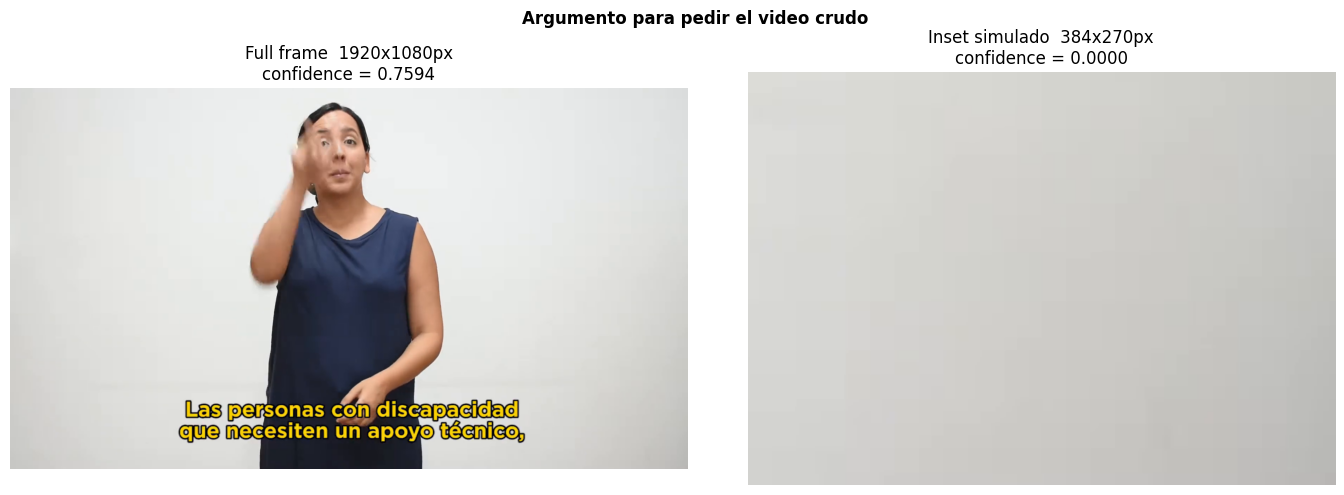

In [4]:
# 6.4 — Simulacion del inset: argumento para pedir el video crudo
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from pathlib import Path

MODELS_DIR = Path('../models')

def confidence_on_frame(frame_rgb):
    opts = mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(MODELS_DIR / 'pose_landmarker.task')),
        running_mode=mp_vision.RunningMode.IMAGE,
    )
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    with mp_vision.PoseLandmarker.create_from_options(opts) as det:
        res = det.detect(mp_img)
    if not res.pose_landmarks: return 0.0, False
    vis = [lm.visibility for lm in res.pose_landmarks[0]]
    return round(float(np.mean(vis)), 4), True

frame_ref = next(f for f in frames if f['pose_detected'] and f['face_detected'])
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_ref['frame'])
ret, frame_bgr = cap.read()
cap.release()
h, w = frame_bgr.shape[:2]
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

# Recuadro tipico de interprete en legislatura (~20% ancho x 25% alto)
inset_w, inset_h = int(w * 0.20), int(h * 0.25)
inset = frame_rgb[h - inset_h:h, w - inset_w:w]

conf_full,  pose_full  = confidence_on_frame(frame_rgb)
conf_inset, pose_inset = confidence_on_frame(inset)

print(f'Full frame  {w}x{h}px    -> confidence: {conf_full:.4f}  | pose: {pose_full}')
print(f'Inset sim   {inset_w}x{inset_h}px  -> confidence: {conf_inset:.4f}  | pose: {pose_inset}')
print(f'Perdida de confidence: {conf_full - conf_inset:+.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(frame_rgb)
axes[0].set_title(f'Full frame  {w}x{h}px\nconfidence = {conf_full:.4f}')
axes[0].axis('off')
axes[1].imshow(inset)
axes[1].set_title(f'Inset simulado  {inset_w}x{inset_h}px\nconfidence = {conf_inset:.4f}')
axes[1].axis('off')
plt.suptitle('Argumento para pedir el video crudo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sección 7 — OCR de subtítulos hardcodeados

Para videos con texto quemado en el frame (sin CC de YouTube).
Corré en orden: **7.1 → 7.2 → 7.3**

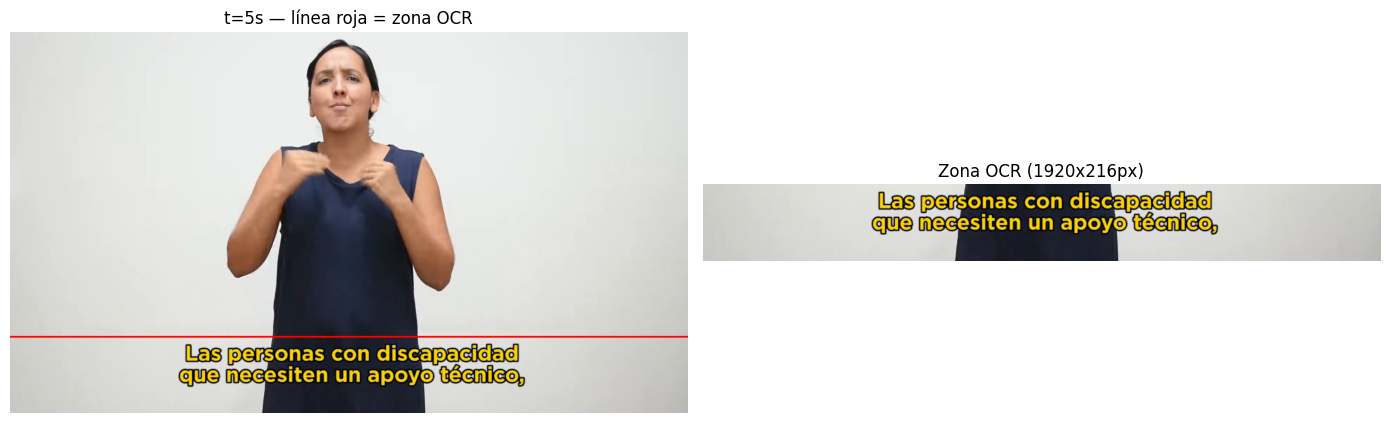

Resolución zona OCR: 1920 x 216 px


In [5]:
# 7.1 — Ver el frame y detectar dónde están los subtítulos
import cv2, numpy as np, matplotlib.pyplot as plt

VIDEO_PATH_OCR = 'data/raw/2iYRa7hKg2g.f137.mp4'
SEGUNDO = 5  # <-- cambiá este número para explorar distintos momentos

cap = cv2.VideoCapture(VIDEO_PATH_OCR)
fps_ocr = cap.get(cv2.CAP_PROP_FPS)
cap.set(cv2.CAP_PROP_POS_FRAMES, int(SEGUNDO * fps_ocr))
ret, frame = cap.read()
cap.release()

h, w = frame.shape[:2]
img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Mostramos el frame con una línea roja marcando dónde recortamos para OCR
CORTE = 0.80  # recortar el último 20% del frame
img_marcado = img.copy()
cv2.line(img_marcado, (0, int(h * CORTE)), (w, int(h * CORTE)), (255, 0, 0), 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_marcado)
axes[0].set_title(f't={SEGUNDO}s — línea roja = zona OCR')
axes[0].axis('off')

sub_region = img[int(h * CORTE):h, :]
axes[1].imshow(sub_region)
axes[1].set_title(f'Zona OCR ({w}x{h - int(h*CORTE)}px)')
axes[1].axis('off')

plt.tight_layout()
plt.show()
print(f'Resolución zona OCR: {w} x {h - int(h * CORTE)} px')

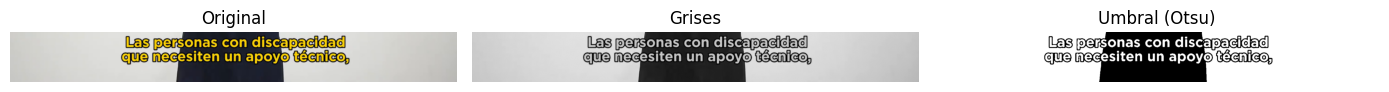

=== OCR sobre imagen original ===
'¡Pasipersonas con discapacidad\nnecesiten un apoyoltécnico!'

=== OCR sobre imagen con umbral ===
'Ilasipersonas con discapacidad\nnecesiten un apoyoltécnico!'


In [6]:
# 7.2 — OCR sobre la zona de subtítulos
import pytesseract

sub_bgr = cv2.cvtColor(sub_region, cv2.COLOR_RGB2BGR)

# Preprocesamiento para mejorar OCR:
# escala de grises → umbral adaptativo → invertir si el texto es blanco sobre oscuro
gray = cv2.cvtColor(sub_bgr, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].imshow(sub_region);  axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(gray, cmap='gray'); axes[1].set_title('Grises'); axes[1].axis('off')
axes[2].imshow(thresh, cmap='gray'); axes[2].set_title('Umbral (Otsu)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

# OCR con configuración para texto en una sola línea
config = '--psm 6 --oem 3'  # psm 6 = bloque de texto uniforme
texto_raw   = pytesseract.image_to_string(sub_region, lang='spa', config=config)
texto_thresh = pytesseract.image_to_string(thresh,    lang='spa', config=config)

print('=== OCR sobre imagen original ===')
print(repr(texto_raw.strip()))
print()
print('=== OCR sobre imagen con umbral ===')
print(repr(texto_thresh.strip()))

In [7]:
# 7.3 — Sincronización: rastrear cuándo cambia el subtítulo segundo a segundo
# Esto muestra si el texto hardcodeado está sincronizado con las señas

config = '--psm 6 --oem 3'
CORTE = 0.80

cap = cv2.VideoCapture(VIDEO_PATH_OCR)
fps_ocr = cap.get(cv2.CAP_PROP_FPS)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
sample = int(fps_ocr)  # 1 frame por segundo

resultados = []
frame_idx = 0
ultimo_texto = ''

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    if frame_idx % sample == 0:
        h, w = frame.shape[:2]
        zona = frame[int(h * CORTE):h, :]
        texto = pytesseract.image_to_string(zona, lang='spa', config=config).strip()
        texto = ' '.join(texto.split())  # normalizar espacios
        t = round(frame_idx / fps_ocr, 1)
        cambio = texto != ultimo_texto
        resultados.append({'t': t, 'texto': texto, 'cambio': cambio})
        ultimo_texto = texto
    frame_idx += 1

cap.release()

print(f'Subtítulos detectados por segundo:')
print(f'  {"Tiempo":8} | {"Cambio":7} | Texto')
print('  ' + '-'*60)
for r in resultados:
    cambio = '<<<' if r['cambio'] and r['texto'] else ''
    texto_disp = r['texto'][:50] if r['texto'] else '(vacío)'
    print(f'  t={r["t"]:4.1f}s  |  {cambio:5}  | {texto_disp}')

con_texto = [r for r in resultados if r['texto']]
print(f'\nFrames con texto detectado: {len(con_texto)}/{len(resultados)}')

Subtítulos detectados por segundo:
  Tiempo   | Cambio  | Texto
  ------------------------------------------------------------
  t= 0.0s  |         | (vacío)
  t= 1.0s  |  <<<    | lasipersonas condiscapacidad necesiten un apoyolté
  t= 1.9s  |  <<<    | ¡lasipersonas con discapacidad necesiten un apoyol
  t= 2.9s  |  <<<    | IPasipersonas con discapacidad necesiten un apoyol
  t= 3.9s  |  <<<    | Ilasipersonas con discapacidad necesiten un apoyol
  t= 4.8s  |         | Ilasipersonas con discapacidad necesiten un apoyol
  t= 5.8s  |  <<<    | ¡Pysipersonas con discapacidad necesiten un apoyol
  t= 6.8s  |  <<<    | puedenisolicitar una ayuda economica all gobiernon
  t= 7.7s  |  <<<    | nuecen Soda MEE scondmica allgobierno nacional!
  t= 8.7s  |  <<<    | nuecen SOTA A TEEN E scondmica allgobierno naciona
  t= 9.7s  |  <<<    | puecen sola LEEN E sScomamica allgobierno nacional
  t=10.6s  |  <<<    | puecen solMHE lA EEN ScoMáÁmica all gobierno nacio
  t=11.6s  |  <<<    | cubrir c

---
## Sección 8 — Toy Dataset: inspección de keypoints

Lee `data/dataset/toy_dataset.json` generado por `build_toy_dataset.py`.  
Si no existe, correlo primero:
```bash
python scripts/build_toy_dataset.py --sample-rate 2
```
Corré en orden: **8.1 → 8.2 → 8.3 → 8.4**

In [ ]:
# 8.1 — Cargar dataset y tabla resumen por video
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import display

TOY_JSON = '../data/dataset/toy_dataset.json'

try:
    toy = json.load(open(TOY_JSON))
    print(f'Entradas cargadas: {len(toy)}')
except FileNotFoundError:
    print(f'No encontrado: {TOY_JSON}')
    print('Corré: python scripts/build_toy_dataset.py --sample-rate 2')
    toy = []

if toy:
    df8 = pd.DataFrame([{
        'source':      e['source'][:28],
        'intent':      e['metadata']['intent'],
        'n_frames':    e['n_frames'],
        'dur_s':       e['metadata']['duration_s'],
        'words':       e['metadata']['word_count'],
        'conf':        e['metadata']['confidence_avg'],
        'pose_%':      round(e['metadata']['pose_pct']*100),
        'cara_%':      round(e['metadata']['face_pct']*100),
        'mano_izq_%':  round(e['metadata']['left_hand_pct']*100),
        'mano_der_%':  round(e['metadata']['right_hand_pct']*100),
    } for e in toy])

    styled = (df8.style
        .background_gradient(subset=['conf'], cmap='RdYlGn', vmin=0.4, vmax=1.0)
        .background_gradient(subset=['pose_%','cara_%'], cmap='RdYlGn', vmin=50, vmax=100)
        .background_gradient(subset=['mano_izq_%','mano_der_%'], cmap='Oranges', vmin=0, vmax=100)
        .format({'conf':'{:.3f}', 'dur_s':'{:.1f}'})
    )
    display(styled)

    print(f"\nTotal: {len(df8)} videos | "
          f"{df8['n_frames'].sum():,} frames | "
          f"conf avg {df8['conf'].mean():.3f} | "
          f"{df8['words'].sum()} palabras")

    # Casos problemáticos
    prob = df8[(df8['conf'] < 0.5) | (df8['pose_%'] < 80)]
    if len(prob):
        print(f'\n⚠  Casos con baja calidad ({len(prob)}):')
        display(prob[['source','conf','pose_%','cara_%']])
    else:
        print('\n✓  Todos los videos superan umbrales mínimos (conf≥0.5, pose≥80%)')


In [ ]:
# 8.2 — Distribución de métricas de keypoints
if toy:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Confidence por video
    colors = plt.cm.RdYlGn([c/1.0 for c in df8['conf']])
    axes[0].barh(df8['source'], df8['conf'], color=colors)
    axes[0].axvline(0.6, color='red', linestyle='--', linewidth=1, label='min 0.6')
    axes[0].set_xlabel('Confidence avg')
    axes[0].set_title('Confidence por video')
    axes[0].legend(fontsize=8)
    axes[0].tick_params(axis='y', labelsize=7)

    # Detección por componente (promedio sobre todos los videos)
    componentes = ['pose_%', 'cara_%', 'mano_izq_%', 'mano_der_%']
    colores_comp = ['steelblue', 'slategray', 'darkorange', 'green']
    medias = [df8[c].mean() for c in componentes]
    axes[1].bar(['Pose','Cara','Mano izq','Mano der'], medias, color=colores_comp)
    axes[1].axhline(80, color='red', linestyle='--', linewidth=1, label='80%')
    axes[1].set_ylim(0, 110)
    axes[1].set_ylabel('% frames detectados (promedio)')
    axes[1].set_title('Detección promedio por componente')
    axes[1].legend(fontsize=8)
    for bar, val in zip(axes[1].patches, medias):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

    # Videos por intent
    intent_counts = df8.groupby('intent')['n_frames'].agg(['count','mean']).reset_index()
    axes[2].bar(intent_counts['intent'], intent_counts['count'], color='steelblue')
    axes[2].set_xticklabels(intent_counts['intent'], rotation=30, ha='right', fontsize=8)
    axes[2].set_ylabel('Cantidad de videos')
    axes[2].set_title('Videos por intent')
    for bar, val in zip(axes[2].patches, intent_counts['count']):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     str(int(val)), ha='center', va='bottom', fontsize=9)

    plt.suptitle('Toy Dataset — métricas de keypoints', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [ ]:
# 8.3 — Calidad por video (pose / cara / manos + confidence)
if toy:
    n = len(toy)
    ids    = [e['source'][:22] for e in toy]
    pose   = [e['metadata']['pose_pct']*100 for e in toy]
    cara   = [e['metadata']['face_pct']*100 for e in toy]
    mano_i = [e['metadata']['left_hand_pct']*100 for e in toy]
    mano_d = [e['metadata']['right_hand_pct']*100 for e in toy]
    confs  = [e['metadata']['confidence_avg'] for e in toy]

    fig, ax = plt.subplots(figsize=(max(12, n*0.6), 5))
    x = np.arange(n)
    w = 0.2
    ax.bar(x - 1.5*w, pose,   w, label='Pose',     color='steelblue')
    ax.bar(x - 0.5*w, cara,   w, label='Cara',     color='slategray')
    ax.bar(x + 0.5*w, mano_i, w, label='Mano izq', color='darkorange')
    ax.bar(x + 1.5*w, mano_d, w, label='Mano der', color='green')

    ax2 = ax.twinx()
    ax2.plot(x, confs, 'r--o', markersize=5, linewidth=1.5, label='Confidence')
    ax2.axhline(0.6, color='red', linestyle=':', alpha=0.4)
    ax2.set_ylim(0, 1.2)
    ax2.set_ylabel('Confidence avg', color='red', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='red')

    ax.set_xticks(x)
    ax.set_xticklabels(ids, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('% frames detectados')
    ax.set_ylim(0, 115)
    ax.axhline(80, color='gray', linestyle=':', alpha=0.5)
    ax.set_title('Calidad de keypoints por video')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


In [ ]:
# 8.4 — Inspección frame a frame: seleccioná video con el dropdown
import ipywidgets as widgets
from IPython.display import display
import cv2, numpy as np, matplotlib.pyplot as plt

LSA_RAW = '../data/lsa_raw/videos'

if toy:
    def unpack_vector(vector, h, w):
        v = np.array(vector, dtype=np.float32)
        to_px = lambda xy: (xy * np.array([w, h])).astype(int)
        return (
            to_px(v[0:66].reshape(33, 2)),
            to_px(v[66:1002].reshape(468, 2)),
            to_px(v[1002:1044].reshape(21, 2)),
            to_px(v[1044:1086].reshape(21, 2)),
        )

    def render(entry_idx, kp_idx):
        e = toy[entry_idx]
        kp_idx = min(kp_idx, e['n_frames'] - 1)
        vector = e['keypoints'][kp_idx]
        fps_v  = e['metadata']['fps'] or 30
        n_kp   = e['n_frames']

        # Estimar frame real en el video (sample_rate puede variar)
        cap = cv2.VideoCapture(f"{LSA_RAW}/{e['source']}.MOV")
        total_v = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        real_frame = int(kp_idx * total_v / n_kp)
        cap.set(cv2.CAP_PROP_POS_FRAMES, real_frame)
        ret, frame = cap.read()
        cap.release()
        if not ret:
            return

        h, w = frame.shape[:2]
        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pose_px, face_px, lhand_px, rhand_px = unpack_vector(vector, h, w)

        for x2, y2 in face_px:
            if x2 > 0 or y2 > 0: cv2.circle(img, (x2, y2), 1, (180,180,180), -1)
        for x2, y2 in pose_px:
            if x2 > 0 or y2 > 0: cv2.circle(img, (x2, y2), 5, (0,150,255), -1)
        for x2, y2 in lhand_px:
            if x2 > 0 or y2 > 0: cv2.circle(img, (x2, y2), 6, (255,120,0), -1)
        for x2, y2 in rhand_px:
            if x2 > 0 or y2 > 0: cv2.circle(img, (x2, y2), 6, (0,220,80), -1)

        v = np.array(vector)
        manos = ('Izq ' if v[1002:1044].any() else '') + ('Der' if v[1044:1086].any() else '') or 'ninguna'
        t_s = round(kp_idx * total_v / n_kp / fps_v, 1)

        with out8:
            out8.clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(13, 7))
            ax.imshow(img)
            ax.set_title(
                f"{e['source']}  |  intent: {e['metadata']['intent']}  |  "
                f"kp {kp_idx}/{n_kp-1}  (~t={t_s}s)\n"
                f"pose={v[0:66].any()} | cara={v[66:1002].any()} | manos: {manos}\n"
                "gris=cara   azul=pose   naranja=mano izq   verde=mano der"
            )
            ax.axis('off')
            plt.tight_layout()
            plt.show()
            plt.close()

    dropdown8 = widgets.Dropdown(
        options=[(e['source'], i) for i, e in enumerate(toy)],
        description='Video:',
        layout=widgets.Layout(width='550px')
    )
    slider8 = widgets.IntSlider(
        min=0, max=toy[0]['n_frames']-1, step=1,
        description='Keypoint:',
        continuous_update=False,
        layout=widgets.Layout(width='550px')
    )
    out8 = widgets.Output()

    def on_drop(change):
        e = toy[change['new']]
        slider8.max = e['n_frames'] - 1
        slider8.value = 0
        render(change['new'], 0)

    def on_slide(change):
        render(dropdown8.value, change['new'])

    dropdown8.observe(on_drop, names='value')
    slider8.observe(on_slide,  names='value')

    display(widgets.VBox([dropdown8, slider8, out8]))
    render(0, 0)
